In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
os.makedirs("out", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

print("cell 1 done", flush=True)

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===", flush=True)
    print("accuracy:", round(accuracy_score(y_test, y_pred), 4), flush=True)
    print("roc_auc:", round(roc_auc_score(y_test, y_prob), 4), flush=True)
    print("pr_auc:", round(average_precision_score(y_test, y_prob), 4), flush=True)
    print(confusion_matrix(y_test, y_pred), flush=True)
    print(classification_report(y_test, y_pred, digits=4), flush=True)

def prep_data(df, target_col, drop_cols=None):
    drop_cols = drop_cols or []
    df = df.copy()
    df = df.dropna(subset=[target_col])

    y = df[target_col].astype(int)
    X = df.drop(columns=[c for c in drop_cols if c in df.columns] + [target_col], errors="ignore")
    X = pd.get_dummies(X, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

    return X, y

def split_and_train(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_lr = scaler.fit_transform(X_train)
    X_test_lr = scaler.transform(X_test)

    lr = LogisticRegression(max_iter=2000, class_weight="balanced")
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    )

    lr.fit(X_train_lr, y_train)
    rf.fit(X_train, y_train)

    return X_train, X_test, X_train_lr, X_test_lr, y_train, y_test, scaler, lr, rf

def shap_lite_lr(model, X_train_lr, X_test_lr, X_test_df, tag):
    bg_n = min(20, len(X_train_lr))
    ex_n = min(20, len(X_test_lr))

    bg = X_train_lr[:bg_n]
    xt = X_test_lr[:ex_n]
    xt_df = X_test_df.iloc[:ex_n]

    explainer = shap.LinearExplainer(model, bg)
    sv = explainer(xt)

    imp = pd.Series(np.abs(sv.values).mean(axis=0), index=xt_df.columns).sort_values(ascending=False)
    print(f"\n{tag} LR SHAP top 10", flush=True)
    print(imp.head(10), flush=True)

    plt.figure(figsize=(10, 6))
    imp.head(10).iloc[::-1].plot(kind="barh")
    plt.title(f"{tag} LR SHAP top 10")
    plt.tight_layout()
    plt.savefig(f"out/{tag.lower()}_lr_shap.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def shap_lite_rf(model, X_train_df, X_test_df, tag):
    bg_n = min(20, len(X_train_df))
    ex_n = min(20, len(X_test_df))

    bg_df = X_train_df.sample(bg_n, random_state=42)
    xt_df = X_test_df.sample(ex_n, random_state=42)

    bg = bg_df.to_numpy(dtype=np.float64)
    xt = xt_df.to_numpy(dtype=np.float64)

    explainer = shap.TreeExplainer(model, data=bg)
    sv = explainer(xt, check_additivity=False)

    vals = sv.values

    # keep only positive class if SHAP returns both classes
    if isinstance(vals, list):
        vals = vals[1]
    elif vals.ndim == 3:
        vals = vals[:, :, 1]

    imp = pd.Series(
        np.abs(vals).mean(axis=0),
        index=xt_df.columns
    ).sort_values(ascending=False)

    print(f"\n{tag} RF SHAP top 10", flush=True)
    print(imp.head(10), flush=True)

    plt.figure(figsize=(10, 6))
    imp.head(10).iloc[::-1].plot(kind="barh")
    plt.title(f"{tag} RF SHAP top 10")
    plt.tight_layout()
    plt.savefig(f"out/{tag.lower()}_rf_shap.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def run_lime(X_train, X_test, model, class_names, tag):
    lime = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X_train.columns.tolist(),
        class_names=class_names,
        mode="classification",
        discretize_continuous=True
    )

    exp = lime.explain_instance(
        X_test.iloc[0].values,
        model.predict_proba,
        num_features=10
    )

    print(f"\n{tag} LIME", flush=True)
    print(exp.as_list(), flush=True)

    with open(f"out/{tag.lower()}_lime.txt", "w") as f:
        f.write(str(exp.as_list()))
        

cell 1 done


In [2]:
print("loading COMPAS", flush=True)

compas = pd.read_csv("compas-scores-two-years.csv")

compas_drop = [
    "id", "name", "first", "last", "dob",
    "c_case_number", "c_offense_date", "c_arrest_date",
    "decile_score_text", "score_text"
]

X_compas, y_compas = prep_data(compas, "two_year_recid", compas_drop)
compas_X_train, compas_X_test, compas_X_train_lr, compas_X_test_lr, compas_y_train, compas_y_test, compas_scaler, compas_lr, compas_rf = split_and_train(X_compas, y_compas)

evaluate(compas_lr, compas_X_test_lr, compas_y_test, "COMPAS - Logistic Regression")
evaluate(compas_rf, compas_X_test, compas_y_test, "COMPAS - Random Forest")

print("cell 2 done", flush=True)

loading COMPAS

=== COMPAS - Logistic Regression ===
accuracy: 0.9647
roc_auc: 0.9946
pr_auc: 0.9924
[[771  22]
 [ 29 621]]
              precision    recall  f1-score   support

           0     0.9637    0.9723    0.9680       793
           1     0.9658    0.9554    0.9606       650

    accuracy                         0.9647      1443
   macro avg     0.9648    0.9638    0.9643      1443
weighted avg     0.9647    0.9647    0.9646      1443


=== COMPAS - Random Forest ===
accuracy: 0.9744
roc_auc: 0.9986
pr_auc: 0.9981
[[756  37]
 [  0 650]]
              precision    recall  f1-score   support

           0     1.0000    0.9533    0.9761       793
           1     0.9461    1.0000    0.9723       650

    accuracy                         0.9744      1443
   macro avg     0.9731    0.9767    0.9742      1443
weighted avg     0.9757    0.9744    0.9744      1443

cell 2 done


starting COMPAS SHAP

COMPAS LR SHAP top 10
is_recid                                      0.941023
event                                         0.689913
end                                           0.653687
r_charge_degree_(M2)                          0.340309
r_charge_degree_(F3)                          0.274197
r_charge_degree_(M1)                          0.236299
r_charge_desc_Driving Under The Influence     0.127460
r_charge_desc_Susp Drivers Lic 1st Offense    0.118883
r_charge_degree_(F2)                          0.116987
r_case_number_14003449CF10A                   0.114892
dtype: float64


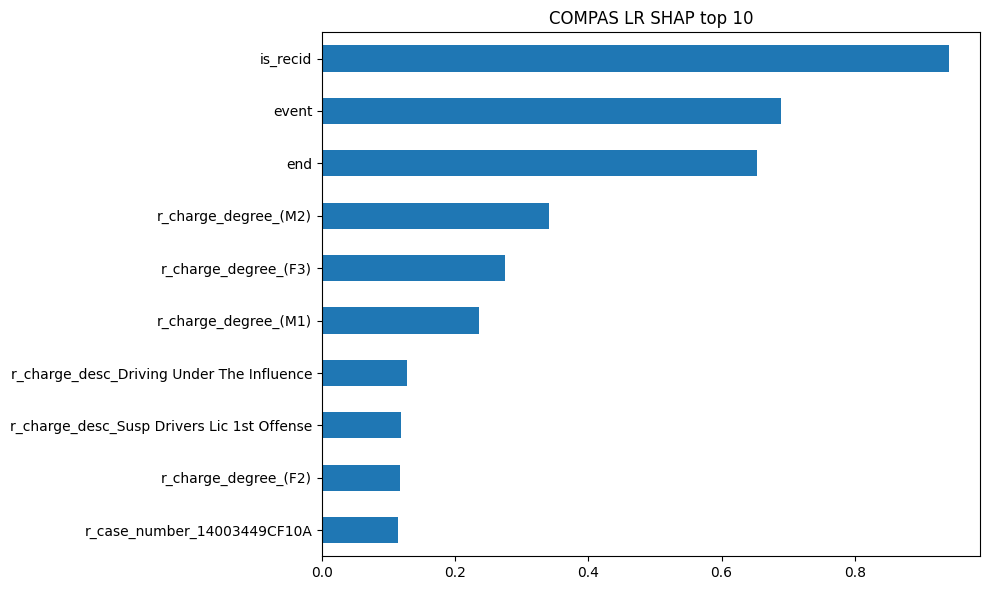


COMPAS RF SHAP top 10
is_recid                                   0.143107
end                                        0.082461
event                                      0.072323
r_charge_degree_(M1)                       0.035924
r_charge_degree_(F3)                       0.027647
r_charge_degree_(M2)                       0.021943
r_days_from_arrest                         0.015502
r_charge_desc_Driving License Suspended    0.011833
r_charge_degree_(F2)                       0.008332
is_violent_recid                           0.007822
dtype: float64


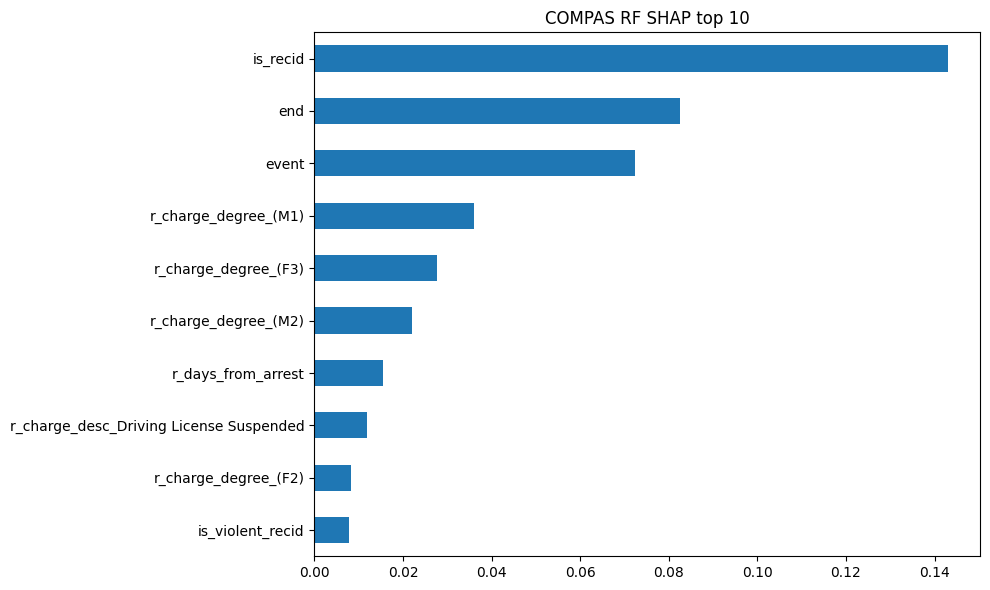

starting COMPAS LIME

COMPAS LIME
[('0.00 < is_recid <= 1.00', 0.26626616324287433), ('0.00 < event <= 1.00', 0.16402330192549525), ('r_charge_degree_(M2) <= 0.00', -0.11979216688528388), ('c_jail_out_2014-10-23 03:13:19 <= 0.00', -0.11896735626678334), ('r_jail_in_2015-04-04 <= 0.00', -0.1017972993386779), ('out_custody_2015-02-04 <= 0.00', 0.0754713175804482), ('v_screening_date_2014-08-17 <= 0.00', 0.027679017597744385), ('screening_date_2014-12-09 <= 0.00', -0.0209117480491315), ('r_jail_out_2014-06-06 <= 0.00', 0.019063542034250976), ('r_jail_out_2013-06-09 <= 0.00', -0.0062087782934585126)]
cell 3 done


In [3]:
print("starting COMPAS SHAP", flush=True)

shap_lite_lr(compas_lr, compas_X_train_lr, compas_X_test_lr, compas_X_test, "COMPAS")
shap_lite_rf(compas_rf, compas_X_train, compas_X_test, "COMPAS")

print("starting COMPAS LIME", flush=True)

run_lime(compas_X_train, compas_X_test, compas_rf, ["No Recidivism", "Recidivism"], "COMPAS")

print("cell 3 done", flush=True)

In [4]:
print("loading fraud", flush=True)

fraud = pd.read_csv("creditcard.csv")

X_fraud, y_fraud = prep_data(fraud, "Class", [])
fraud_X_train, fraud_X_test, fraud_X_train_lr, fraud_X_test_lr, fraud_y_train, fraud_y_test, fraud_scaler, fraud_lr, fraud_rf = split_and_train(X_fraud, y_fraud)

evaluate(fraud_lr, fraud_X_test_lr, fraud_y_test, "Fraud - Logistic Regression")
evaluate(fraud_rf, fraud_X_test, fraud_y_test, "Fraud - Random Forest")

print("cell 4 done", flush=True)

loading fraud

=== Fraud - Logistic Regression ===
accuracy: 0.9755
roc_auc: 0.9721
pr_auc: 0.719
[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962


=== Fraud - Random Forest ===
accuracy: 0.9995
roc_auc: 0.9471
pr_auc: 0.8583
[[56861     3]
 [   25    73]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962

cell 4 done


starting Fraud SHAP

Fraud LR SHAP top 10
V10       1.376600
V14       1.366496
V1        1.338196
V5        1.183791
V4        1.164394
Amount    1.090287
V12       0.971540
V17       0.810005
V6        0.807606
V2        0.734448
dtype: float64


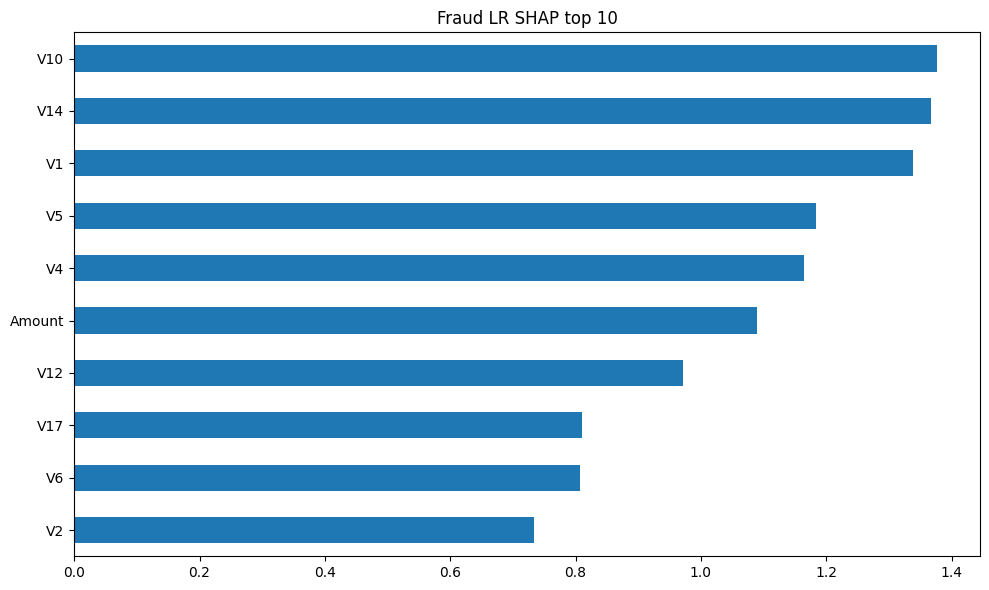


Fraud RF SHAP top 10
V4     0.000448
V12    0.000344
V14    0.000340
V13    0.000331
V11    0.000325
V9     0.000242
V3     0.000232
V1     0.000215
V8     0.000210
V21    0.000193
dtype: float64


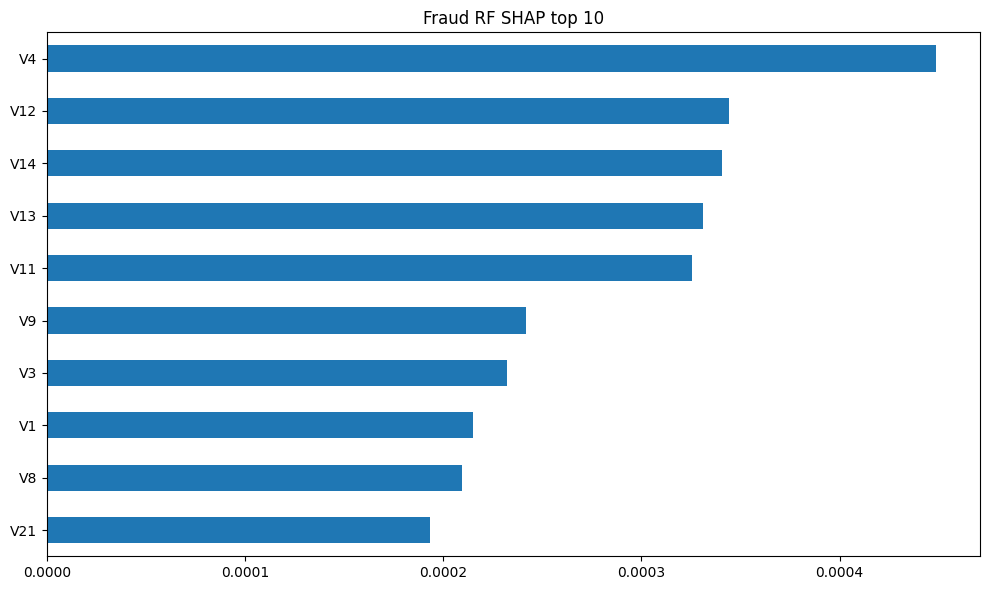

starting Fraud LIME

Fraud LIME
[('V17 <= -0.48', 0.0024583862617576727), ('V4 <= -0.85', -0.0015580492080771989), ('V3 <= -0.89', 0.0015298627599509285), ('-0.65 < V13 <= -0.01', -0.0006707321810497336), ('V7 > 0.57', 0.0006173811628096617), ('V10 > 0.45', -0.0006070310959881787), ('V20 > 0.13', -0.0005045868319317222), ('V11 <= -0.76', -0.00046796034810824293), ('-0.92 < V1 <= 0.02', -0.00046173803448926236), ('22.00 < Amount <= 77.49', -0.00039515851933983015)]
cell 5 done


In [5]:
print("starting Fraud SHAP", flush=True)

shap_lite_lr(fraud_lr, fraud_X_train_lr, fraud_X_test_lr, fraud_X_test, "Fraud")
shap_lite_rf(fraud_rf, fraud_X_train, fraud_X_test, "Fraud")

print("starting Fraud LIME", flush=True)

run_lime(fraud_X_train, fraud_X_test, fraud_rf, ["Legit", "Fraud"], "Fraud")

print("cell 5 done", flush=True)

In [6]:
summary = pd.DataFrame([
    [
        "COMPAS",
        "Logistic Regression",
        accuracy_score(compas_y_test, compas_lr.predict(compas_X_test_lr)),
        roc_auc_score(compas_y_test, compas_lr.predict_proba(compas_X_test_lr)[:, 1]),
        average_precision_score(compas_y_test, compas_lr.predict_proba(compas_X_test_lr)[:, 1]),
    ],
    [
        "COMPAS",
        "Random Forest",
        accuracy_score(compas_y_test, compas_rf.predict(compas_X_test)),
        roc_auc_score(compas_y_test, compas_rf.predict_proba(compas_X_test)[:, 1]),
        average_precision_score(compas_y_test, compas_rf.predict_proba(compas_X_test)[:, 1]),
    ],
    [
        "Fraud",
        "Logistic Regression",
        accuracy_score(fraud_y_test, fraud_lr.predict(fraud_X_test_lr)),
        roc_auc_score(fraud_y_test, fraud_lr.predict_proba(fraud_X_test_lr)[:, 1]),
        average_precision_score(fraud_y_test, fraud_lr.predict_proba(fraud_X_test_lr)[:, 1]),
    ],
    [
        "Fraud",
        "Random Forest",
        accuracy_score(fraud_y_test, fraud_rf.predict(fraud_X_test)),
        roc_auc_score(fraud_y_test, fraud_rf.predict_proba(fraud_X_test)[:, 1]),
        average_precision_score(fraud_y_test, fraud_rf.predict_proba(fraud_X_test)[:, 1]),
    ],
], columns=["Dataset", "Model", "Accuracy", "ROC_AUC", "PR_AUC"])

print(summary)
summary.to_csv("q1_explainability_results.csv", index=False)
print("cell 6 done", flush=True)

  Dataset                Model  Accuracy   ROC_AUC    PR_AUC
0  COMPAS  Logistic Regression  0.964657  0.994645  0.992365
1  COMPAS        Random Forest  0.974359  0.998583  0.998075
2   Fraud  Logistic Regression  0.975528  0.972083  0.718971
3   Fraud        Random Forest  0.999508  0.947055  0.858255
cell 6 done
